# Semana 2 -- Cohortes y Retencion

Matriz triangular de retencion por cohorte de primera compra (Tarea 1), sobre `base_analitica` y la `FECHA_CORTE` fijadas en los Quality Checks (Josefina).

## Setup -- conexion y carga de `base_analitica` / `FECHA_CORTE`

In [1]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

con = duckdb.connect("../olist.duckdb")

base_analitica = con.execute("select * from marts.base_analitica").df()
FECHA_CORTE = con.execute("select max(fecha_compra) from marts.base_analitica").fetchone()[0]

print(f"Órdenes en base_analítica: {len(base_analitica):,}")
print(f"FECHA_CORTE = {FECHA_CORTE}")

Órdenes en base_analítica: 98,207
FECHA_CORTE = 2018-09-03


In [2]:
base_analitica.head()

,order_id,customer_unique_id,fecha_compra,order_status,cantidad_items,valor_productos,valor_flete,valor_total
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,2017-10-02,delivered,1,29.99,8.72,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,2018-07-24,delivered,1,118.70,22.76,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,2018-08-08,delivered,1,159.90,19.22,179.12
3,ad21c59c0840e6cb83a9ceb5573f8159,72632f0f9dd73dfee390c9b22eb56dd6,2018-02-13,delivered,1,19.90,8.72,28.62
4,a4591c265e18cb1dcee52889e2d8acc3,80bb27c7c16e8f973207a5086ab329e2,2017-07-09,delivered,1,147.90,27.36,175.26


**Paso 1** -- `first_order_month` por cliente, desde `base_analitica`

**Importante:** se calcula desde `base_analitica` (ya filtrada), no desde `dim_cliente.fecha_primera_compra` -- esa columna se armo en la Semana 1 sobre `fct_ordenes` **sin filtrar**. Un cliente cuya primera orden haya sido `canceled`/`unavailable`, pero que despues si compro de verdad, quedaria mal asignado a una cohorte donde no tiene ninguna orden real.

In [3]:
first_order = con.execute("""
    select
        customer_unique_id,
        date_trunc('month', min(fecha_compra)) as first_order_month
    from marts.base_analitica
    group by customer_unique_id
""").df()

print(f"Clientes con first_order_month: {len(first_order):,}")

Clientes con first_order_month: 94,990


In [4]:
first_order.head()

,customer_unique_id,first_order_month
0,04cf8185c71090d28baa4407b2e6d600,2018-03-01
1,3e4fd73f1e86b135b9b121d6abbe9597,2017-11-01
2,a464f750556546a0989d9326ec003ccf,2018-06-01
3,bb4d84a2b45b22ed710ac8c0dec63d1a,2017-07-01
4,52a7fb2dfa60628b04619fa279d3e27c,2017-12-01


**Paso 2** -- `months_since_first_order` por orden:

In [5]:
cohortes = base_analitica.merge(first_order, on="customer_unique_id", how="inner")

cohortes["order_month"] = cohortes["fecha_compra"].values.astype("datetime64[M]")

cohortes["months_since_first_order"] = (
    (cohortes["order_month"].dt.year - cohortes["first_order_month"].dt.year) * 12 + (cohortes["order_month"].dt.month - cohortes["first_order_month"].dt.month)
)

print(len(cohortes))

cohortes[["customer_unique_id", "fecha_compra", "first_order_month", "months_since_first_order"]].head()

98207


,customer_unique_id,fecha_compra,first_order_month,months_since_first_order
0,7c396fd4830fd04220f754e42b4e5bff,2017-10-02,2017-09-01,1
1,af07308b275d755c9edb36a90c618231,2018-07-24,2018-07-01,0
2,3a653a41f6f9fc3d2a113cf8398680e8,2018-08-08,2018-08-01,0
3,72632f0f9dd73dfee390c9b22eb56dd6,2018-02-13,2018-02-01,0
4,80bb27c7c16e8f973207a5086ab329e2,2017-07-09,2017-07-01,0


In [6]:
cohortes.head()

,order_id,customer_unique_id,fecha_compra,order_status,cantidad_items,valor_productos,valor_flete,valor_total,first_order_month,order_month,months_since_first_order
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,2017-10-02,delivered,1,29.99,8.72,38.71,2017-09-01,2017-10-01,1
1,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,2018-07-24,delivered,1,118.70,22.76,141.46,2018-07-01,2018-07-01,0
2,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,2018-08-08,delivered,1,159.90,19.22,179.12,2018-08-01,2018-08-01,0
3,ad21c59c0840e6cb83a9ceb5573f8159,72632f0f9dd73dfee390c9b22eb56dd6,2018-02-13,delivered,1,19.90,8.72,28.62,2018-02-01,2018-02-01,0
4,a4591c265e18cb1dcee52889e2d8acc3,80bb27c7c16e8f973207a5086ab329e2,2017-07-09,delivered,1,147.90,27.36,175.26,2017-07-01,2017-07-01,0


**Paso 3** -- Agrupar por cohorte y mes relativo, y contar clientes distintos

In [7]:
conteo_cohortes = (
    cohortes
    .groupby(["first_order_month","months_since_first_order"])["customer_unique_id"]
    .nunique()
    .reset_index(name="clientes")
)

In [8]:
conteo_cohortes.head(10)

,first_order_month,months_since_first_order,clientes
0,2016-09-01,0,2
1,2016-10-01,0,290
2,2016-10-01,6,1
3,2016-10-01,9,1
4,2016-10-01,11,1
5,2016-10-01,13,1
6,2016-10-01,15,1
7,2016-10-01,17,1
8,2016-10-01,19,2
9,2016-10-01,20,2


In [9]:
conteo_cohortes.loc[conteo_cohortes["months_since_first_order"] == 0, "clientes"].sum()

np.int64(94990)

**Paso 4** -- Pivotar: de tabla larga a matriz

In [10]:
matriz_conteo = conteo_cohortes.pivot(
    index="first_order_month",
    columns="months_since_first_order",
    values="clientes"
)

matriz_conteo

months_since_first_order,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
first_order_month,,,,,,,,,,,,,,,,,,,,
2016-09-01,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10-01,290.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,2.0,2.0
2016-12-01,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01-01,752.0,3.0,2.0,1.0,3.0,1.0,3.0,1.0,1.0,NaN,3.0,1.0,5.0,3.0,1.0,1.0,2.0,3.0,1.0,NaN
2017-02-01,1690.0,4.0,5.0,2.0,7.0,2.0,4.0,3.0,2.0,3.0,2.0,5.0,2.0,3.0,2.0,1.0,1.0,4.0,NaN,NaN
2017-03-01,2571.0,13.0,9.0,10.0,9.0,4.0,4.0,8.0,9.0,2.0,10.0,3.0,6.0,3.0,4.0,6.0,2.0,4.0,NaN,NaN
2017-04-01,2325.0,14.0,5.0,4.0,7.0,6.0,8.0,7.0,7.0,4.0,6.0,2.0,2.0,1.0,2.0,2.0,3.0,NaN,NaN,NaN
2017-05-01,3541.0,17.0,17.0,14.0,11.0,12.0,15.0,5.0,9.0,9.0,9.0,12.0,9.0,1.0,7.0,8.0,NaN,NaN,NaN,NaN
2017-06-01,3102.0,14.0,11.0,12.0,8.0,12.0,11.0,7.0,4.0,7.0,10.0,10.0,5.0,4.0,6.0,NaN,NaN,NaN,NaN,NaN


`FECHA_CORTE` no es un parámetro que se pueda "mover" para conseguir más columnas (y tener menos `NaN`) -- es el límite físico real de la data: el 3 de setiembre de 2018 es la última fecha con una órden válida (**no canceled/unavailable**) en todo el dataset, si extendiaron el tiempo se estaría inventando data.

**Paso 5a** -- Recortar cohortes de borde (2016: muy pocos clientes, puro ruido estadistico)

In [11]:
# Recortar cohortes de 2016 (muy chicas ~ ruido)
matriz_conteo = matriz_conteo.loc[matriz_conteo.index >= "2017-01-01"]

In [12]:
matriz_conteo

months_since_first_order,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
first_order_month,,,,,,,,,,,,,,,,,,,,
2017-01-01,752.0,3.0,2.0,1.0,3.0,1.0,3.0,1.0,1.0,NaN,3.0,1.0,5.0,3.0,1.0,1.0,2.0,3.0,1.0,NaN
2017-02-01,1690.0,4.0,5.0,2.0,7.0,2.0,4.0,3.0,2.0,3.0,2.0,5.0,2.0,3.0,2.0,1.0,1.0,4.0,NaN,NaN
2017-03-01,2571.0,13.0,9.0,10.0,9.0,4.0,4.0,8.0,9.0,2.0,10.0,3.0,6.0,3.0,4.0,6.0,2.0,4.0,NaN,NaN
2017-04-01,2325.0,14.0,5.0,4.0,7.0,6.0,8.0,7.0,7.0,4.0,6.0,2.0,2.0,1.0,2.0,2.0,3.0,NaN,NaN,NaN
2017-05-01,3541.0,17.0,17.0,14.0,11.0,12.0,15.0,5.0,9.0,9.0,9.0,12.0,9.0,1.0,7.0,8.0,NaN,NaN,NaN,NaN
2017-06-01,3102.0,14.0,11.0,12.0,8.0,12.0,11.0,7.0,4.0,7.0,10.0,10.0,5.0,4.0,6.0,NaN,NaN,NaN,NaN,NaN
2017-07-01,3822.0,20.0,13.0,9.0,11.0,8.0,12.0,4.0,7.0,10.0,8.0,11.0,5.0,10.0,NaN,NaN,NaN,NaN,NaN,NaN
2017-08-01,4130.0,28.0,14.0,11.0,15.0,22.0,12.0,11.0,6.0,6.0,10.0,8.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-09-01,4075.0,28.0,22.0,12.0,18.0,9.0,9.0,10.0,12.0,7.0,11.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Paso 5b** -- Enmascarar las celdas que todavia no pudieron observarse (esto es lo que arma la forma triangular): dentro de la ventana valida, `NaN` pasa a ser `0` ("nadie volvio ese mes"); fuera de la ventana valida (el futuro respecto de `FECHA_CORTE`), se deja en blanco porque no dio tiempo de medirlo.

In [13]:
# Celdas que matemáticamente no pudieron observarse
FECHA_CORTE_ts = pd.Timestamp(FECHA_CORTE)
meses_transcurridos = (
    (FECHA_CORTE_ts.year - matriz_conteo.index.year) * 12 + (FECHA_CORTE_ts.month - matriz_conteo.index.month)
)

mask_valida = matriz_conteo.columns.values <= meses_transcurridos.values.reshape(-1, 1)
matriz_conteo = matriz_conteo.fillna(0).where(mask_valida)

In [14]:
matriz_conteo

months_since_first_order,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
first_order_month,,,,,,,,,,,,,,,,,,,,
2017-01-01,752.0,3.0,2.0,1.0,3.0,1.0,3.0,1.0,1.0,0.0,3.0,1.0,5.0,3.0,1.0,1.0,2.0,3.0,1.0,0.0
2017-02-01,1690.0,4.0,5.0,2.0,7.0,2.0,4.0,3.0,2.0,3.0,2.0,5.0,2.0,3.0,2.0,1.0,1.0,4.0,0.0,NaN
2017-03-01,2571.0,13.0,9.0,10.0,9.0,4.0,4.0,8.0,9.0,2.0,10.0,3.0,6.0,3.0,4.0,6.0,2.0,4.0,NaN,NaN
2017-04-01,2325.0,14.0,5.0,4.0,7.0,6.0,8.0,7.0,7.0,4.0,6.0,2.0,2.0,1.0,2.0,2.0,3.0,0.0,NaN,NaN
2017-05-01,3541.0,17.0,17.0,14.0,11.0,12.0,15.0,5.0,9.0,9.0,9.0,12.0,9.0,1.0,7.0,8.0,0.0,NaN,NaN,NaN
2017-06-01,3102.0,14.0,11.0,12.0,8.0,12.0,11.0,7.0,4.0,7.0,10.0,10.0,5.0,4.0,6.0,0.0,NaN,NaN,NaN,NaN
2017-07-01,3822.0,20.0,13.0,9.0,11.0,8.0,12.0,4.0,7.0,10.0,8.0,11.0,5.0,10.0,0.0,NaN,NaN,NaN,NaN,NaN
2017-08-01,4130.0,28.0,14.0,11.0,15.0,22.0,12.0,11.0,6.0,6.0,10.0,8.0,5.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN
2017-09-01,4075.0,28.0,22.0,12.0,18.0,9.0,9.0,10.0,12.0,7.0,11.0,3.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Paso 6** -- Dividir cada cohorte por su propio tamano (M0) para obtener el % de retencion

In [15]:
matriz_pct = matriz_conteo.div(matriz_conteo[0], axis=0) * 100

In [16]:
matriz_pct

months_since_first_order,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
first_order_month,,,,,,,,,,,,,,,,,,,,
2017-01-01,100.0,0.398936,0.265957,0.132979,0.398936,0.132979,0.398936,0.132979,0.132979,0.000000,0.398936,0.132979,0.664894,0.398936,0.132979,0.132979,0.265957,0.398936,0.132979,0.0
2017-02-01,100.0,0.236686,0.295858,0.118343,0.414201,0.118343,0.236686,0.177515,0.118343,0.177515,0.118343,0.295858,0.118343,0.177515,0.118343,0.059172,0.059172,0.236686,0.000000,NaN
2017-03-01,100.0,0.505640,0.350058,0.388954,0.350058,0.155581,0.155581,0.311163,0.350058,0.077791,0.388954,0.116686,0.233372,0.116686,0.155581,0.233372,0.077791,0.155581,NaN,NaN
2017-04-01,100.0,0.602151,0.215054,0.172043,0.301075,0.258065,0.344086,0.301075,0.301075,0.172043,0.258065,0.086022,0.086022,0.043011,0.086022,0.086022,0.129032,0.000000,NaN,NaN
2017-05-01,100.0,0.480090,0.480090,0.395369,0.310647,0.338887,0.423609,0.141203,0.254165,0.254165,0.254165,0.338887,0.254165,0.028241,0.197684,0.225925,0.000000,NaN,NaN,NaN
2017-06-01,100.0,0.451322,0.354610,0.386847,0.257898,0.386847,0.354610,0.225661,0.128949,0.225661,0.322373,0.322373,0.161186,0.128949,0.193424,0.000000,NaN,NaN,NaN,NaN
2017-07-01,100.0,0.523286,0.340136,0.235479,0.287807,0.209314,0.313972,0.104657,0.183150,0.261643,0.209314,0.287807,0.130822,0.261643,0.000000,NaN,NaN,NaN,NaN,NaN
2017-08-01,100.0,0.677966,0.338983,0.266344,0.363196,0.532688,0.290557,0.266344,0.145278,0.145278,0.242131,0.193705,0.121065,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
2017-09-01,100.0,0.687117,0.539877,0.294479,0.441718,0.220859,0.220859,0.245399,0.294479,0.171779,0.269939,0.073620,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Paso 7** -- Heatmap. Se excluye M0 (siempre 100%, no aporta informacion) y se ancla `vmax` a un techo mayor al maximo real de los datos (~0.7%) para no exagerar visualmente el ruido de muestra chica.

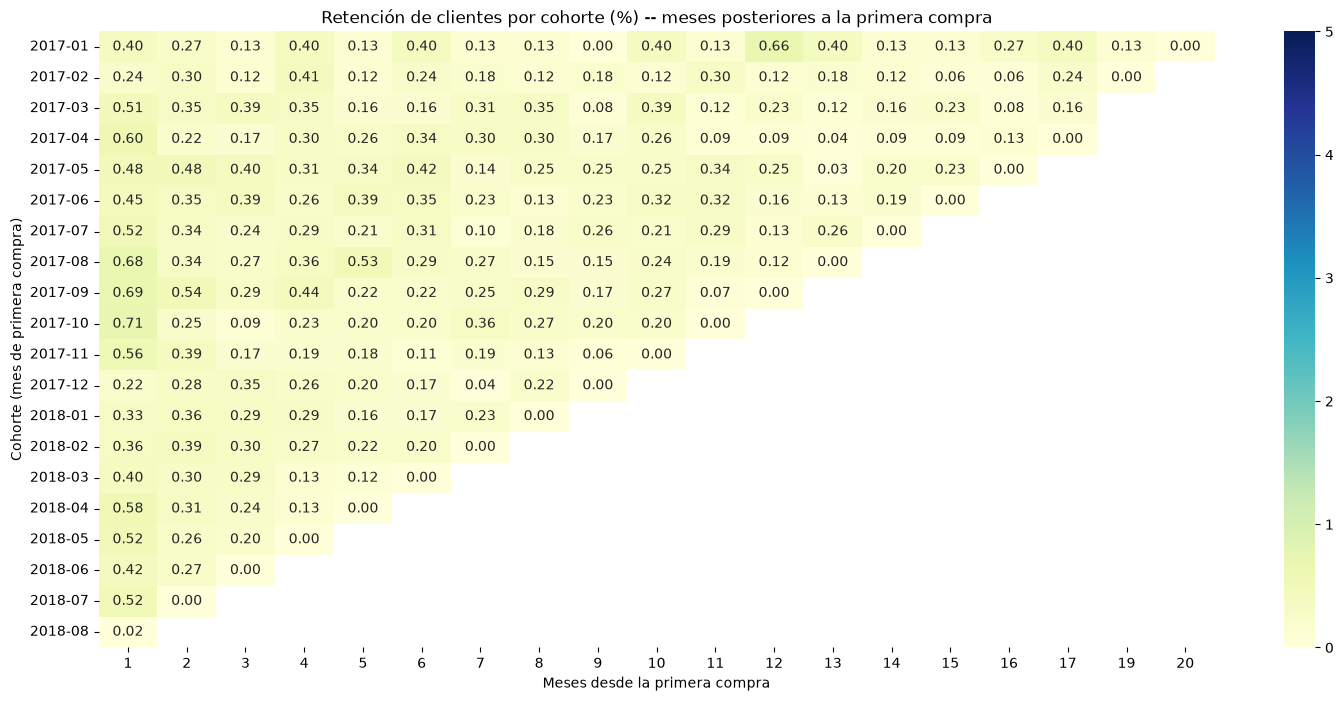

In [17]:
matriz_pct_sin_m0 = matriz_pct.drop(columns=0).copy()
matriz_pct_sin_m0.index = matriz_pct_sin_m0.index.strftime("%Y-%m")

plt.figure(figsize=(18, 8))
sns.heatmap(
    matriz_pct_sin_m0,
    annot=True, fmt=".2f",
    cmap="YlGnBu",
    vmin=0, vmax=5, # ancho deliberadamente mayor al máximo real (~0.7%), no auto-ajustado
    mask=matriz_pct_sin_m0.isna()
)
plt.title("Retención de clientes por cohorte (%) -- meses posteriores a la primera compra")
plt.xlabel("Meses desde la primera compra")
plt.ylabel("Cohorte (mes de primera compra)")
plt.show()

El heatmap cumple su propósito (el cual no era buscar un patrón dramático) -- era verificar si existe o no un patrón, y la respuesta es *no, es parejo y bajo por todos lados*.

- Confirma que la matriz está bien construída (_ya que si no hubieramos hecho un manejo previo de los `NaN` y `0` el heatmap hubiera sido un rectángulo con agujeros sin sentido_)
- El la Semana 1, calculamos que el $3.12$ % de los clientes recompra alguna vez. Ahora, sabemos que *esta recompra no está concentrada en ningún mes en específico*
- Esto es la base para la tarea 2 y 3. Recién ahora, sabiendo que el panorama es "bajo y parejo", tiene sentido preguntarse por (Tarea 2): ¿Hay alguna categoría, geografía o ticket que rompa este patrón?

## Tarea 2

**Objetivo:** partir la misma pregunta de retencion de la Tarea 1 (volvio a comprar o no) en 3 cortes -- categoria de primera compra, geografia (estado), ticket de primera compra -- para ver si alguno rompe el patron parejo y bajo que ya encontramos.

**Cambio de diseno respecto a la Tarea 1:** no se arma cohorte (mes) x segmento x mes relativo -- eso serian 3 matrices enormes e innecesarias, porque la Tarea 1 ya mostro que el tiempo calendario no importa (retencion pareja en todas las cohortes). Aca se agrupa directo por **segmento x mes relativo**, juntando todas las cohortes dentro de cada segmento.

Paso 1 -- traer `customer_state` a `cohortes` y calcular `meses_transcurridos` por cliente:

In [18]:
FECHA_CORTE_ts = pd.Timestamp(FECHA_CORTE)

first_order["meses_transcurridos"] = (
    (FECHA_CORTE_ts.year - first_order["first_order_month"].dt.year) * 12 + (FECHA_CORTE_ts.month - first_order["first_order_month"].dt.month)
)

clientes_geo = first_order.merge(
    con.execute('select customer_unique_id, customer_state from marts.dim_cliente').df(),
    on="customer_unique_id", how="left"
)

In [19]:
first_order.head()

,customer_unique_id,first_order_month,meses_transcurridos
0,04cf8185c71090d28baa4407b2e6d600,2018-03-01,6
1,3e4fd73f1e86b135b9b121d6abbe9597,2017-11-01,10
2,a464f750556546a0989d9326ec003ccf,2018-06-01,3
3,bb4d84a2b45b22ed710ac8c0dec63d1a,2017-07-01,14
4,52a7fb2dfa60628b04619fa279d3e27c,2017-12-01,9


In [20]:
clientes_geo.head()

,customer_unique_id,first_order_month,meses_transcurridos,customer_state
0,04cf8185c71090d28baa4407b2e6d600,2018-03-01,6,SP
1,3e4fd73f1e86b135b9b121d6abbe9597,2017-11-01,10,SP
2,a464f750556546a0989d9326ec003ccf,2018-06-01,3,SP
3,bb4d84a2b45b22ed710ac8c0dec63d1a,2017-07-01,14,SP
4,52a7fb2dfa60628b04619fa279d3e27c,2017-12-01,9,SP


Revisión de integridad (previo):

In [21]:
print(len(clientes_geo)) # esperado --> 94,990
print(clientes_geo["customer_state"].isna().sum()) # esperado -> 0

94990
0


Agrupando por `customer_state` en lugar de por cohorte:

In [22]:
cohortes_geo = cohortes.merge(
    clientes_geo[["customer_unique_id", "customer_state"]],
    on="customer_unique_id", how="left"
)

In [23]:
cohortes_geo.head()

,order_id,customer_unique_id,fecha_compra,order_status,cantidad_items,valor_productos,valor_flete,valor_total,first_order_month,order_month,months_since_first_order,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,2017-10-02,delivered,1,29.99,8.72,38.71,2017-09-01,2017-10-01,1,SP
1,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,2018-07-24,delivered,1,118.70,22.76,141.46,2018-07-01,2018-07-01,0,BA
2,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,2018-08-08,delivered,1,159.90,19.22,179.12,2018-08-01,2018-08-01,0,GO
3,ad21c59c0840e6cb83a9ceb5573f8159,72632f0f9dd73dfee390c9b22eb56dd6,2018-02-13,delivered,1,19.90,8.72,28.62,2018-02-01,2018-02-01,0,SP
4,a4591c265e18cb1dcee52889e2d8acc3,80bb27c7c16e8f973207a5086ab329e2,2017-07-09,delivered,1,147.90,27.36,175.26,2017-07-01,2017-07-01,0,PR


Esto arma el **numerador**: cuantos clientes de cada estado compraron en cada mes relativo `M` (mismo `groupby` que la Tarea 1, cambiando `first_order_month` por `customer_state`).

In [24]:

conteo_geo = (
    cohortes_geo
    .groupby(["customer_state", "months_since_first_order"])["customer_unique_id"]
    .nunique()
    .reset_index(name="clientes")
)

conteo_geo.head(10)

,customer_state,months_since_first_order,clientes
0,AC,0,77
1,AC,2,1
2,AC,3,1
3,AC,10,1
4,AL,0,399
5,AL,1,1
6,AL,5,1
7,AL,7,2
8,AL,8,1
9,AM,0,142


**El denominador ya no es un numero fijo por fila** (a diferencia de la Tarea 1, donde alcanzaba con la columna M0). Aca cada fila es un estado, y un estado mezcla clientes de cohortes distintas -- asi que "cuantos clientes hay en total" cambia segun que mes `M` se pregunte.

- **Numerador** (`conteo_geo`): columna `M` = cuantos clientes **volvieron a comprar** en el mes relativo `M`.
- **Denominador** (`denominador_geo`): columna `M` = cuantos clientes **ya tienen `M` meses o mas de antiguedad** (`meses_transcurridos >= M`) -- o sea, a cuantos les corresponde preguntarles por ese mes.

No es la misma pregunta en cada tabla, por eso son dos tablas separadas que recien despues se dividen. Sin este ajuste, un estado con muchos clientes nuevos se veria con retencion artificialmente baja en los meses altos, aunque los clientes viejos si vuelvan -- se estaria dividiendo por gente que todavia no tuvo la oportunidad de aparecer en el numerador.

In [25]:
max_m = conteo_geo["months_since_first_order"].max()

denominador_geo = pd.DataFrame({
    m: clientes_geo.loc[clientes_geo["meses_transcurridos"] >= m]
                    .groupby("customer_state")["customer_unique_id"]
                    .nunique()
    for m in range(max_m + 1)
})

In [26]:
denominador_geo.head()

,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
customer_state,,,,,,,,,,,,,,,,,,,,,
AC,77,77,74,70,67,65,62,60,58,52,...,42,36,31,27,22,19,11,6,4,1.0
AL,399,399,384,361,337,321,293,263,236,200,...,163,136,117,99,83,73,48,26,16,4.0
AM,142,142,138,120,114,105,99,90,83,71,...,55,52,43,38,33,32,23,10,5,NaN
AP,67,67,65,59,57,51,46,41,39,28,...,20,17,16,13,12,10,5,5,2,NaN
BA,3243,3243,3081,2844,2653,2415,2200,1959,1756,1528,...,1109,948,783,633,484,385,265,174,86,28.0


In [27]:
perfil_primera = con.execute("""
    with base as (
        select order_id, customer_unique_id, fecha_compra, valor_total
        from marts.base_analitica
    ),
    n_ord as (   -- ¿cuántas órdenes hizo en total? (para saber si recompró)
        select customer_unique_id, count(distinct order_id) as n_ordenes
        from base group by 1
    ),
    primera as (  -- la PRIMERA orden de cada cliente
        select customer_unique_id, order_id, valor_total,
               row_number() over (partition by customer_unique_id
                                   order by fecha_compra, order_id) as rn
        from base
        qualify rn = 1
    ),
    cat_primera as (  -- categoría del ítem más caro de esa primera orden
        select p.customer_unique_id,
               d.product_category_name_english as categoria,
               row_number() over (partition by p.customer_unique_id
                                   order by i.valor_producto desc) as rn_item
        from primera p
        join marts.fct_items i on i.order_id = p.order_id
        left join marts.dim_producto d on d.product_id = i.product_id
        qualify rn_item = 1
    )
    select
        p.customer_unique_id,
        p.valor_total                          as ticket_primera,
        coalesce(c.categoria, 'sin_categoria') as categoria_primera,
        cl.customer_state,
        n.n_ordenes,
        (n.n_ordenes >= 2)                     as recompro
    from primera p
    left join cat_primera c  on c.customer_unique_id = p.customer_unique_id
    left join marts.dim_cliente cl on cl.customer_unique_id = p.customer_unique_id
    left join n_ord n on n.customer_unique_id = p.customer_unique_id
""").df()

In [28]:
print(f"Clientes en el perfil: {len(perfil_primera):,}")
print(f"Tasa de recompra global: {perfil_primera['recompro'].mean()*100:.2f}%")  # esperado ~3.1%
perfil_primera.head(10)

Clientes en el perfil: 94,990
Tasa de recompra global: 3.04%


,customer_unique_id,ticket_primera,categoria_primera,customer_state,n_ordenes,recompro
0,ee4203bde8734078a27485ea2b641398,34.79,sports_leisure,SP,1,False
1,778a5135345d4387a2749cd2816ec1c2,96.80,stationery,RS,1,False
2,e4c2f9f473b32b696e65abdc8c51296e,123.10,health_beauty,SP,1,False
3,9154ece329f3c5af30b08af0de64ce99,385.75,cool_stuff,MG,1,False
4,7aea85f90d8be9a2265587f19b7c0598,48.00,home_appliances,RS,1,False
5,fd900b490aa7416cdec68bc136bc3334,604.50,health_beauty,SP,1,False
6,1e8ae2128137cd86fb6cc9d0445fcf7c,417.55,consoles_games,RJ,1,False
7,a48ce24144099b583b6150e0f69712d4,41.32,health_beauty,RJ,1,False
8,990228d4f60cef7388323d8fc67d7169,53.37,bed_bath_table,SP,1,False
9,e1d0eca650e05f1e10cad6bce9b48e0a,233.69,housewares,DF,1,False


Referencia (Línea contra la que comparamos todo)

In [29]:
tasa_global = perfil_primera["recompro"].mean() * 100
print(tasa_global)

3.0403200336877565


**Interpretación — línea base de comparación.**

El **3,04 %** es la tasa de recompra global: de cada 100 clientes que hicieron su primera compra, ~3 volvieron a comprar al menos una vez más (medido sobre `customer_unique_id`, universo reconciliado de 94.990 clientes). Es la **vara** contra la que se leen los tres cortes siguientes:

- barra **por encima** de la línea roja → el segmento retiene *mejor* que el promedio;
- barra **por debajo** → retiene *peor*.

Confirma además el ~3,12 % ya calculado en la Semana 1: la base es consistente.

Recompra por categoría de la 1a compra:

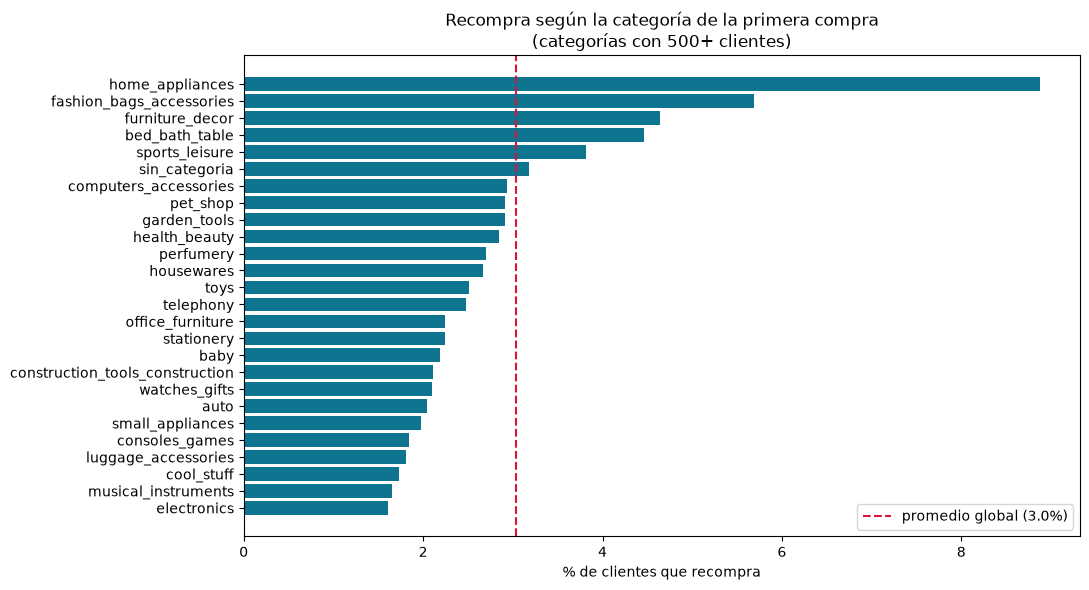

In [30]:
cat = (perfil_primera.groupby("categoria_primera")
       .agg(clientes=("recompro", "size"), recompra=("recompro", "mean")))

cat["recompra"] *= 100
cat_top = cat[cat["clientes"] >= 500].sort_values("recompra", ascending=False)

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(cat_top.index, cat_top["recompra"], color="#0e7490")
ax.axvline(tasa_global, ls="--", color="crimson", label=f"promedio global ({tasa_global:.1f}%)")
ax.set_xlabel("% de clientes que recompra")
ax.set_title("Recompra según la categoría de la primera compra\n(categorías con 500+ clientes)")
ax.invert_yaxis(); ax.legend()
plt.tight_layout(); plt.show()

**Interpretación — la categoría de la primera compra SÍ discrimina la retención.** *(hallazgo principal de la Tarea 2)*

Es el único de los tres cortes que rompe el patrón plano del 3 %:

- **Se despegan hacia arriba:** electrodomésticos (`home_appliances`) retiene ~**8,9 %** — casi **3× el promedio** —, seguido de moda/accesorios (~5,7 %), decoración (~4,6 %) y baño/dormitorio (~4,5 %).
- **Se hunden hacia abajo (~mitad del promedio):** electrónica, instrumentos musicales, `cool_stuff` y consolas (~1,6–1,9 %).

**Lectura de negocio:** *lo que el cliente compra la primera vez predice si vuelve.* Las categorías de hogar y consumo recurrente construyen relación; las de compra puntual o de regalo se agotan en una sola transacción.

**Matiz honesto:** incluso la categoría líder sigue siendo baja en términos absolutos (<1 de cada 11 vuelve). La categoría **reordena** un número que, a nivel Olist, es estructuralmente chico — no lo transforma.

Recompra por ticket de la 1a compra (Cuartiles)

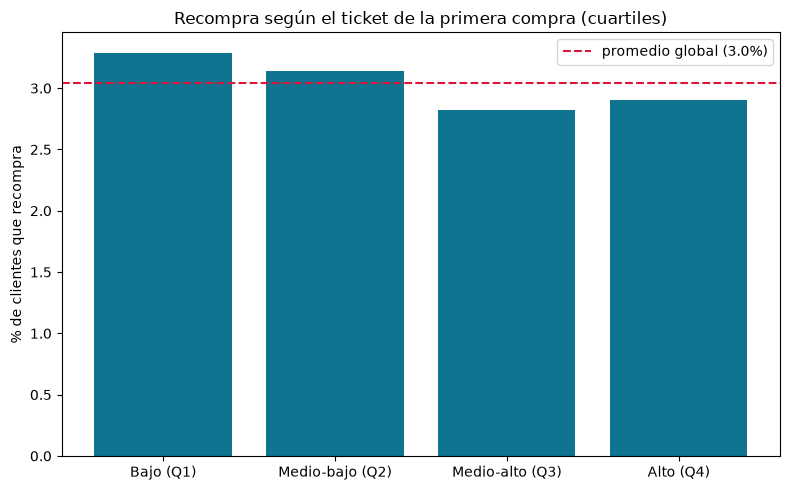

In [31]:
perfil_primera["ticket_bucket"] = pd.qcut(
    perfil_primera["ticket_primera"], 4,
    labels=["Bajo (Q1)", "Medio-bajo (Q2)", "Medio-alto (Q3)", "Alto (Q4)"]
)

tk = perfil_primera.groupby("ticket_bucket", observed=True)["recompro"].mean() * 100

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(tk.index.astype(str), tk.values, color="#0e7490")
ax.axhline(tasa_global, ls="--", color="crimson", label=f"promedio global ({tasa_global:.1f}%)")
ax.set_ylabel("% de clientes que recompra")
ax.set_title("Recompra según el ticket de la primera compra (cuartiles)")
ax.legend()
plt.tight_layout(); plt.show()

**Interpretación — el ticket de la primera compra NO explica la retención.**

Los cuatro cuartiles se mantienen pegados a la línea del 3 % (rango ~2,8 %–3,3 %). Existe una levísima tendencia inversa (los tickets bajos vuelven un poco más que los altos), pero la diferencia es de ~0,5 pp: **dentro del ruido, sin valor accionable.**

**Lectura de negocio:** cuánto gasta un cliente la primera vez no predice si vuelve. Un ticket alto no es señal de lealtad — muchas veces es una compra grande y única. No conviene priorizar retención por monto gastado.

Recomprar por estado:

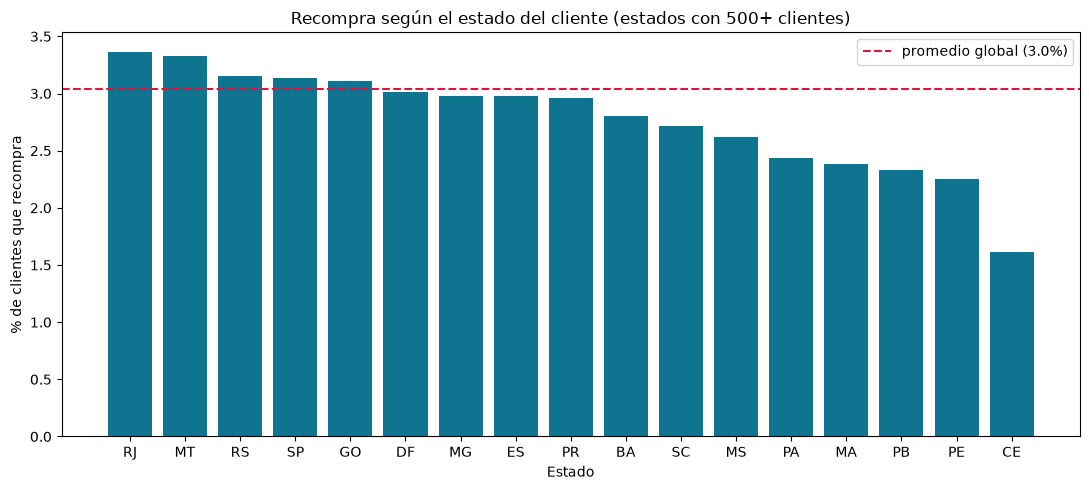

In [32]:
geo = (perfil_primera.groupby("customer_state")
       .agg(clientes=("recompro", "size"), recompra=("recompro", "mean")))

geo["recompra"] *= 100
geo_top = geo[geo["clientes"] >= 500].sort_values("recompra", ascending=False)

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(geo_top.index, geo_top["recompra"], color="#0e7490")
ax.axhline(tasa_global, ls="--", color="crimson", label=f"promedio global ({tasa_global:.1f}%)")
ax.set_ylabel("% de clientes que recompra"); ax.set_xlabel("Estado")
ax.set_title("Recompra según el estado del cliente (estados con 500+ clientes)")
ax.legend()
plt.tight_layout(); plt.show()

**Interpretación — la geografía es una palanca débil.**

La mayoría de los estados con masa suficiente orbitan el promedio (≈2,3 %–3,4 %), sin una región claramente "campeona" de retención. El único caso que se despega con claridad —hacia abajo— es **Ceará (`CE`, ~1,6 %)**.

**Lectura de negocio:** no hay un patrón regional lo bastante fuerte como para segmentar la estrategia de retención por estado. La ubicación del cliente aporta poco frente a la categoría de su primera compra.

## Cierre — Tarea 2: hallazgo global

> **La retención se explica por _qué_ compra el cliente, no por _cuánto_ gasta ni _dónde_ vive.**

De los tres cortes analizados sobre la primera compra, solo uno mueve la aguja:

| Corte | ¿Rompe el patrón? | Conclusión |
|---|---|---|
| **Categoría** | ✅ Sí | Electrodomésticos/hogar retienen hasta ~3× el promedio; electrónica/consolas, la mitad. |
| **Ticket** | ❌ No | Plano en los 4 cuartiles (~3 %). El monto inicial no predice recompra. |
| **Geografía** | 🟡 Apenas | Todos orbitan el promedio; solo Ceará (`CE`) se hunde. Palanca menor. |

**Implicancia de negocio.** Si el objetivo es aumentar la recompra, la palanca no es descuento por monto ni foco regional, sino el **mix de categoría de entrada**: atraer y activar clientes en categorías de hogar/consumo recurrente, y diseñar un segundo contacto específico para quienes entran por categorías de compra única (electrónica, consolas, regalos).

**Límite a tener presente.** Todo esto reordena un piso de recompra que, a nivel Olist, es estructuralmente bajo (~3 %). La categoría mejora las probabilidades relativas, pero el negocio sigue siendo de **compra mayormente única** — coherente con lo hallado en la Tarea 1 (retención baja y pareja en el tiempo).

## Tarea 3 - LTV por cohorte

Mismo esqueleto que la Tarea 1, pero la métrica de cada celda cambia.
En vez de *cuánto clientes volvieron*, medimos el **revenue acumulado promedio por cliente** de la cohorte a lo largo de los meses.

Reutilizamos `cohortes` y el tamaño de cohorte `matriz_conteo[0]` para que el LTV reconcilie con la matriz de retención

---

LTV = **Lifetime Value** (valor del ciclo de vida del cliente)

Es el total de dinero que un cliente deja a lo largo de toda su relación con el negocio, no solo en la primera compra. **Responde a la pregunta**: "_cada cliente que capto, ¿cuánto revenue me genera en total con el tiempo?_"

---

revenue por cohorte x mes relativo $\rightarrow$ matriz + máscara

In [33]:
# Revenue (suma de `valor_total`) por cohorte y mes relativo - mismo groupby que T1
revenue_cohortes = (
    cohortes
    .groupby(["first_order_month", "months_since_first_order"])["valor_total"]
    .sum()
    .reset_index(name="revenue")
)

matriz_revenue = revenue_cohortes.pivot(
    index="first_order_month",
    columns="months_since_first_order",
    values="revenue"
)

# Mismo recorte de 2016 y misma máscara triangula que la tarea 1
matriz_revenue = matriz_revenue.loc[matriz_revenue.index >= "2017-01-01"]

meses_transcurridos_rev = (
    (FECHA_CORTE_ts.year - matriz_revenue.index.year) * 12 + (FECHA_CORTE_ts.month - matriz_revenue.index.month)
)

mask_valida_rev = matriz_revenue.columns.values <= meses_transcurridos_rev.values.reshape(-1,1)
matriz_revenue = matriz_revenue.fillna(0).where(mask_valida_rev)

matriz_revenue

months_since_first_order,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
first_order_month,,,,,,,,,,,,,,,,,,,,
2017-01-01,136923.84,170.83,114.70,89.70,246.25,69.33,448.43,105.17,47.05,0.00,427.05,66.60,552.45,351.65,93.70,104.61,219.35,354.43,50.93,0.0
2017-02-01,283390.86,536.12,570.63,118.73,1151.96,74.21,688.92,274.30,464.61,385.35,343.22,454.39,279.24,397.11,181.66,136.79,291.68,536.16,0.00,NaN
2017-03-01,424967.14,1794.97,1737.12,1836.10,1213.97,1433.39,689.18,887.42,1447.49,237.96,1103.10,380.30,947.71,238.58,687.41,717.55,203.88,472.85,NaN,NaN
2017-04-01,403282.01,2937.00,940.40,758.21,1388.64,1208.34,2083.80,1096.55,963.99,499.82,692.56,343.17,488.66,271.64,301.83,272.63,962.61,0.00,NaN,NaN
2017-05-01,577671.73,1981.77,3046.03,2039.15,1270.79,1698.01,3024.03,608.02,1623.52,1353.84,1459.06,1438.36,1173.14,62.33,803.36,915.92,0.00,NaN,NaN,NaN
2017-06-01,493672.68,1973.51,2060.14,1433.12,1374.89,1627.85,1601.41,822.86,346.26,570.50,2348.45,1946.68,513.44,909.63,2284.89,0.00,NaN,NaN,NaN,NaN
2017-07-01,570883.24,3070.50,1307.59,1156.32,1220.36,1865.65,2553.19,250.36,413.96,2071.11,1163.02,1264.85,1409.38,981.78,0.00,NaN,NaN,NaN,NaN,NaN
2017-08-01,651117.61,5056.77,2229.03,1014.62,1858.42,2911.98,1864.71,1949.83,1800.03,1204.91,1460.16,1825.60,595.78,0.00,NaN,NaN,NaN,NaN,NaN,NaN
2017-09-01,705758.80,3659.33,3182.57,1793.32,3226.19,2055.93,1067.34,965.33,1218.00,695.80,1336.99,326.30,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Interpretación — el revenue se concentra brutalmente en M0.**

Cada fila muestra el revenue de una cohorte por mes relativo. La columna **M0 domina todo**: la cohorte 2017-01 factura **R$ 136.923** en su primer mes, y luego apenas **R$ 90–250 por mes** en los meses siguientes. Los meses posteriores a la primera compra aportan migajas frente al mes de adquisición.

Los `NaN` de la esquina inferior derecha son la **máscara triangular** (misma que la Tarea 1): meses que aún no se pudieron observar respecto de `FECHA_CORTE`. No son ceros — son "todavía no medible".

acumular y dividir por el tamaño de cohorte $\rightarrow$ LTV

In [34]:
tam_cohorte = matriz_conteo[0]      # M0 = n° de clientes de cada cohorte (ya recortado + enmascarado en T1)

revenue_acum = matriz_revenue.cumsum(axis=1)        # acumulado en el tiempo; los NaN de cola se mantienen en NaN
matriz_ltv = revenue_acum.div(tam_cohorte, axis=0)   # revenue acumulado promedio por CLIENTE de la cohorte

matriz_ltv.round(2)

months_since_first_order,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,19,20
first_order_month,,,,,,,,,,,,,,,,,,,,
2017-01-01,182.08,182.31,182.46,182.58,182.91,183.00,183.59,183.73,183.80,183.80,184.36,184.45,185.19,185.66,185.78,185.92,186.21,186.68,186.75,186.75
2017-02-01,167.69,168.00,168.34,168.41,169.09,169.14,169.55,169.71,169.98,170.21,170.41,170.68,170.85,171.08,171.19,171.27,171.44,171.76,171.76,NaN
2017-03-01,165.29,165.99,166.67,167.38,167.85,168.41,168.68,169.02,169.59,169.68,170.11,170.26,170.62,170.72,170.98,171.26,171.34,171.53,NaN,NaN
2017-04-01,173.45,174.72,175.12,175.45,176.05,176.57,177.46,177.93,178.35,178.56,178.86,179.01,179.22,179.34,179.47,179.58,180.00,180.00,NaN,NaN
2017-05-01,163.14,163.70,164.56,165.13,165.49,165.97,166.83,167.00,167.46,167.84,168.25,168.66,168.99,169.01,169.23,169.49,169.49,NaN,NaN,NaN
2017-06-01,159.15,159.78,160.45,160.91,161.35,161.88,162.39,162.66,162.77,162.95,163.71,164.34,164.50,164.80,165.53,165.53,NaN,NaN,NaN,NaN
2017-07-01,149.37,150.17,150.51,150.82,151.14,151.62,152.29,152.36,152.46,153.01,153.31,153.64,154.01,154.27,154.27,NaN,NaN,NaN,NaN,NaN
2017-08-01,157.66,158.88,159.42,159.67,160.12,160.82,161.27,161.74,162.18,162.47,162.83,163.27,163.41,163.41,NaN,NaN,NaN,NaN,NaN,NaN
2017-09-01,173.19,174.09,174.87,175.31,176.10,176.61,176.87,177.11,177.41,177.58,177.90,177.98,177.98,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Interpretación — el LTV nace casi completo y crece poquísimo.**

Dividiendo el revenue acumulado por el tamaño de la cohorte, el LTV por cliente arranca en **R$ 150–182 en M0** y se mueve muy poco después. La cohorte más antigua (2017-01) va de **R$ 182,08 en M0 a R$ 186,75 en M20**: en **20 meses** sumó solo **R$ 4,67 (+2,6 %)**.

Dicho de otro modo: **~97 % del valor de un cliente Olist se captura en su primera compra.** La diferencia de LTV entre cohortes (150 vs. 182) responde al **ticket promedio de entrada** (qué compraron), no a la retención — todas retienen casi nada.

Curvas superpuestas

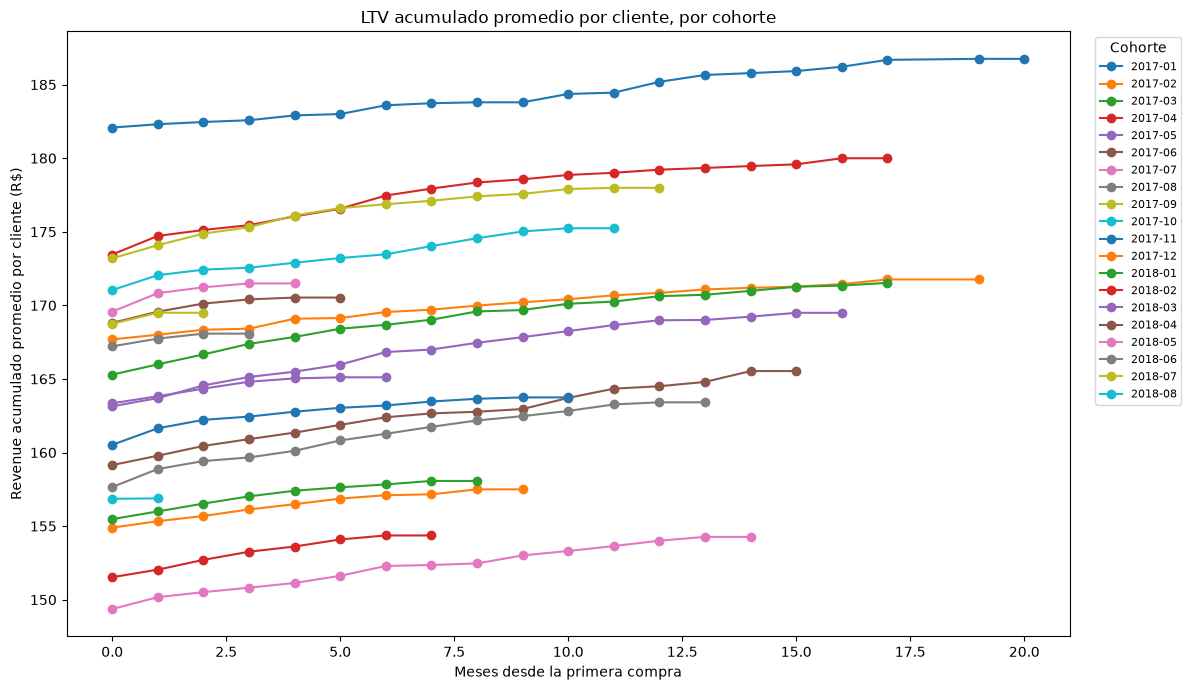

In [35]:
plt.figure(figsize=(12, 7))
for cohorte in matriz_ltv.index:
    serie = matriz_ltv.loc[cohorte].dropna()    # dropna corta la línea donde termina la ventana observable
    plt.plot(serie.index, serie.values, marker="o", label=cohorte.strftime("%Y-%m"))

plt.title("LTV acumulado promedio por cliente, por cohorte")
plt.xlabel("Meses desde la primera compra")
plt.ylabel("Revenue acumulado promedio por cliente (R$)")
plt.legend(title="Cohorte", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

**Interpretación — curvas casi horizontales.**

Cada línea es una cohorte. El patrón es inequívoco: **todas se aplanan apenas pasan M0**. No hay una sola cohorte cuya curva "despegue" con el tiempo. Las líneas más cortas son las cohortes recientes (2018), cortadas por la ventana de observación — no es que caigan, es que todavía no las pudimos seguir 12 meses.

**Lectura de negocio:** Olist no acumula valor por cliente a lo largo del tiempo. El modelo es de **compra esencialmente única** — coherente con la retención ~3 % de las Tareas 1 y 2.

hitos 3 / 6 / 12 meses

In [36]:
ltv_hitos = matriz_ltv.reindex(columns=[3,6,12]).copy()
ltv_hitos.index = ltv_hitos.index.strftime("%Y-%m")
ltv_hitos.columns = ["LTV_3m", "LTV_6m", "LTV_12m"]
ltv_hitos.round(2)

,LTV_3m,LTV_6m,LTV_12m
first_order_month,,,
2017-01,182.58,183.59,185.19
2017-02,168.41,169.55,170.85
2017-03,167.38,168.68,170.62
2017-04,175.45,177.46,179.22
2017-05,165.13,166.83,168.99
2017-06,160.91,162.39,164.50
2017-07,150.82,152.29,154.01
2017-08,159.67,161.27,163.41
2017-09,175.31,176.87,177.98


**Interpretación — LTV_3m ≈ LTV_6m ≈ LTV_12m.**

Los tres hitos son casi idénticos dentro de cada cohorte. Ejemplo 2017-01: **R$ 182,58 (3m) → 183,59 (6m) → 185,19 (12m)** — el año entero de "vida" del cliente agrega **R$ 2,61 (+1,4 %)** sobre lo del tercer mes.

Los `NaN` en `LTV_6m`/`LTV_12m` de las cohortes nuevas son **honestos**: no tuvieron 6/12 meses de exposición antes de `FECHA_CORTE`, y **no se rellenan** (rellenar con 0 mentiría a la baja; con un promedio, inventaría). Mismo criterio triangular de la Tarea 1.

**Implicancia para el negocio (y el deck):** para proyectar valor de cliente, **el horizonte relevante es el primer mes**, no el primer año. Cualquier inversión en adquisición debe recuperarse casi con la primera compra, porque no hay una "cola" de recompra que la financie después.

## Tarea 4 — Tiempo entre compras (1ª → 2ª)

Para los clientes que **recompraron** (2+ órdenes en `base_analitica`), medimos los **días entre su primera y su segunda compra**, y miramos la **distribución completa** (no solo el promedio). El promedio de Semana 1 (80,3 días) esconde la forma: lo que decide una campaña de re-enganche es *cuándo* se concentra la recompra, no el número medio.

In [37]:
# Días entre 1ª y 2ª compra — solo clientes que recompraron
tiempo_entre = con.execute("""
    with ordenes_rank as (
        select customer_unique_id, fecha_compra,
               row_number() over (partition by customer_unique_id
                                   order by fecha_compra, order_id) as rn
        from marts.base_analitica
    ),
    primera as (select customer_unique_id, fecha_compra as fecha_1 from ordenes_rank where rn = 1),
    segunda as (select customer_unique_id, fecha_compra as fecha_2 from ordenes_rank where rn = 2)
    select
        p.customer_unique_id,
        date_diff('day', p.fecha_1, s.fecha_2) as dias_entre_compras
    from primera p
    join segunda s using (customer_unique_id)   -- inner join: filtra a los que recompraron
""").df()

print(f"Clientes que recompraron: {len(tiempo_entre):,}")
tiempo_entre["dias_entre_compras"].describe().round(1)

Clientes que recompraron: 2,888


count    2888.0
mean       80.8
std       110.3
min         0.0
25%         0.0
50%        28.0
75%       125.0
max       609.0
Name: dias_entre_compras, dtype: float64

**Interpretación — la mediana (28 días) manda, no la media (81).**

De los **2.888** clientes que recompraron, la media es **80,8 días** pero la **mediana es 28**. Esa brecha (media ≫ mediana) delata una distribución **muy sesgada a la derecha**: la mayoría vuelve rápido y una minoría con gaps larguísimos (hasta **609 días**) estira el promedio. El promedio de 80 días de Semana 1 era real, pero **engañoso**: no describe al cliente típico.

Dato llamativo: el **percentil 25 es 0 días** → al menos 1 de cada 4 recompradores hace su 2ª orden el **mismo día** que la 1ª (probablemente una compra partida / ítem olvidado, más que fidelidad real).

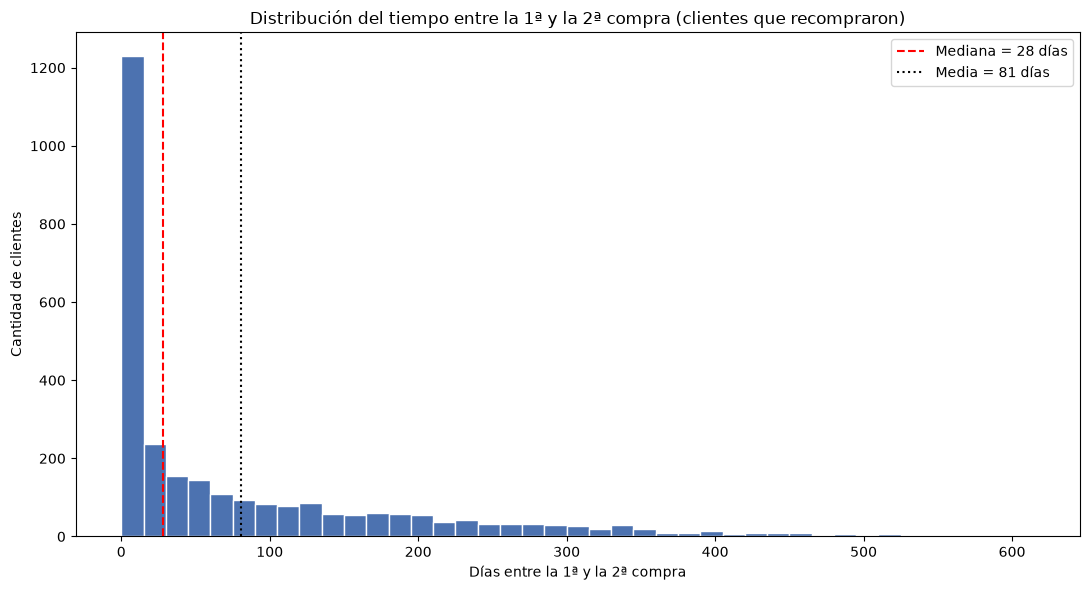

In [38]:
mediana = tiempo_entre["dias_entre_compras"].median()
media   = tiempo_entre["dias_entre_compras"].mean()
tope    = int(tiempo_entre["dias_entre_compras"].max())

plt.figure(figsize=(11, 6))
plt.hist(tiempo_entre["dias_entre_compras"], bins=range(0, tope + 16, 15),
         color="#4C72B0", edgecolor="white")
plt.axvline(mediana, color="red",   linestyle="--", label=f"Mediana = {mediana:.0f} días")
plt.axvline(media,   color="black", linestyle=":",  label=f"Media = {media:.0f} días")
plt.title("Distribución del tiempo entre la 1ª y la 2ª compra (clientes que recompraron)")
plt.xlabel("Días entre la 1ª y la 2ª compra")
plt.ylabel("Cantidad de clientes")
plt.legend()
plt.tight_layout()
plt.show()

**Interpretación — pico temprano + cola larga.**

El histograma confirma la forma: una **concentración fuerte en las primeras semanas** y una **cola** que se arrastra más de un año y medio. La línea roja (mediana, 28 d) cae mucho antes que la negra (media, 81 d); visualmente, la media vive *a la derecha* del grueso de la masa, arrastrada por esa cola. Es el caso de manual donde **la media miente y la mediana describe**.

In [39]:
# ¿Qué porcentaje de los que recompran vuelve dentro de X días?
for d in [30, 60, 90, 180]:
    pct = (tiempo_entre["dias_entre_compras"] <= d).mean() * 100
    print(f"Vuelven dentro de {d:>3} días: {pct:5.1f}%")

Vuelven dentro de  30 días:  50.9%
Vuelven dentro de  60 días:  61.4%
Vuelven dentro de  90 días:  68.3%
Vuelven dentro de 180 días:  82.9%


**Interpretación — la ventana de recompra es el primer mes.**

- **50,9 %** de los recompradores vuelve dentro de **30 días**
- 61,4 % dentro de 60 · 68,3 % dentro de 90 · 82,9 % dentro de 180

Más de la mitad de la 2ª compra ocurre en el **primer mes**. **Implicancia de negocio:** si hay una acción de re-enganche, su ventana útil son los **primeros 30 días** post-compra — no el día 80 (la media), que ya llega tarde para la mayoría. Pasados ~6 meses, una segunda compra es marginal.

**Matiz honesto:** esto describe solo al **~3 % que recompra** (2.888 de ~94.990). Para el otro 97 % no hay 2ª compra. El titular de la semana no cambia: casi nadie vuelve; de los pocos que vuelven, lo hacen **rápido (dentro del primer mes) o casi nunca**.

## Cierre — Semana 2: hallazgos globales

Las cuatro tareas cuentan **una sola historia coherente** sobre la base de clientes de Olist:

| Tarea | Pregunta | Hallazgo |
|---|---|---|
| **T1 — Cohortes** | ¿Cuándo vuelven? | Retención **baja y pareja (~3 %)**, sin concentrarse en ningún mes. |
| **T2 — Variaciones** | ¿Quién vuelve? | Lo explica **qué** compra (categoría: hogar ~3× el promedio; electrónica/consolas la mitad), **no cuánto** (ticket plano) ni **dónde** (geografía plana). |
| **T3 — LTV** | ¿Cuánto valen? | **~97 % del valor** del cliente está en la **primera compra**; las curvas de LTV se aplanan apenas pasa M0. |
| **T4 — Tiempo entre compras** | Si vuelven, ¿cuándo? | Mediana **28 días**: el que recompra lo hace **dentro del primer mes** (51 % ≤ 30 d), o casi nunca. |

**Síntesis para el negocio.** Olist es un negocio de **compra esencialmente única**. La retención es un piso estructuralmente bajo que la categoría de entrada *reordena* pero no *transforma*. Dos palancas accionables:

1. **La adquisición debe pagarse con la primera compra** — no hay una cola de recompra que la financie después (T3).
2. **Si se invierte en re-enganche, la ventana son los primeros 30 días** y conviene apuntar a categorías de consumo recurrente (T2 + T4).

**Visualizaciones (DoD ≥ 5):** heatmap de cohortes (T1) · 3 barras de recompra categoría/ticket/estado (T2) · curvas de LTV por cohorte (T3) · histograma de tiempo entre compras (T4) = **6 visualizaciones** ✅